<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>LLM Engineering Masterclass</h1>
<h1>6. LLMOps: Tracing, Cost, Caching and CI</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [15]:
import os
import hashlib
import json
import time
import uuid
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import watermark
from tqdm.auto import tqdm

# Data downloads/cache and figure output locations
_ROOT = Path.cwd()
_DATA = _ROOT / "data"
_OUT = _ROOT / "output"
_DATA.mkdir(parents=True, exist_ok=True)
_OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(_DATA / "huggingface"))
os.environ.setdefault("HF_DATASETS_CACHE", str(_DATA / "huggingface" / "datasets"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(_DATA / "kagglehub"))

from collections import Counter
from pprint import pprint

%load_ext watermark
%matplotlib inline


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


In [16]:
%watermark -n -v -m -g -iv


Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.17.1

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 4a6dba6ecf328d3e09b6b48d7053d924ebc0545f

json      : 2.0.9
matplotlib: 3.11.1
numpy     : 2.5.3
openai    : 3.13.0
pandas    : 3.0.5
tqdm      : 4.70.1
watermark : 2.6.0



In [17]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# Ship it, then see it

Production asks questions a notebook never does. What did this request cost? Where did the latency go? Did last week's prompt change move quality?

Three jobs cover it:

1. **Observe**: trace every call with tokens, cost and latency.
2. **Control**: cache what repeats, bound what waits, degrade instead of failing.
3. **Gate**: run the eval harness in CI so regressions die in review.

Everything here is plain Python and one JSONL file. Swap in a tracing platform later. The discipline transfers unchanged.

# A flight recorder for model calls

In [18]:
TRACE_PATH = _OUT / "trace.jsonl"

PRICE_PER_1M = {  # USD per million tokens. Prices move. Check your provider page.
    "gpt-4.1-mini": {"in": 0.40, "out": 1.60},
    "gpt-4.1-nano": {"in": 0.10, "out": 0.40},
}

RUN_ID = uuid.uuid4().hex[:8]

def log_event(**fields):
    fields["run_id"] = RUN_ID
    fields["timestamp"] = time.time()
    with TRACE_PATH.open("a") as fp:
        fp.write(json.dumps(fields) + "\n")

from openai import OpenAI

openai_client = OpenAI()

def llm(messages, model="gpt-4.1-mini", stage="default", **kwargs):
    """The call helper from Notebook 1, now with a flight recorder."""
    start = time.perf_counter()
    response = openai_client.chat.completions.create(
        model=model, messages=messages, temperature=0, **kwargs
    )
    latency = time.perf_counter() - start
    usage = response.usage
    price = PRICE_PER_1M.get(model, {"in": 0.0, "out": 0.0})
    cost = (usage.prompt_tokens * price["in"] + usage.completion_tokens * price["out"]) / 1e6
    log_event(kind="llm_call", stage=stage, model=model,
              tokens_in=usage.prompt_tokens, tokens_out=usage.completion_tokens,
              latency_s=round(latency, 3), cost_usd=round(cost, 6))
    return response.choices[0].message.content

print("Run id:", RUN_ID)


Run id: e1e62da3


# Generate some traffic

Fifteen real Banking77 messages stand in for a minute of production.

In [19]:
taxonomy = json.loads((_DATA / "banking77_taxonomy.json").read_text())
test = pd.read_csv(_DATA / "banking77_test.csv")

SYSTEM = ("You triage customer messages for a mobile banking app. "
          "Reply with the queue only: " + ", ".join(taxonomy["queues"]) + ".")

# A slice of real traffic: 15 messages sampled from the test split.
messages = test["text"].sample(15, random_state=20260912).tolist()

queues = []
for text in tqdm(messages):
    queues.append(llm(
        [{"role": "system", "content": SYSTEM},
         {"role": "user", "content": text}],
        stage="triage",
    ))

report = llm(
    [{"role": "user",
      "content": "Summarize this queue list in one sentence: " + ", ".join(queues)}],
    stage="report",
)
print(report)


  0%|          | 0/15 [00:00<?, ?it/s]

The queue list primarily consists of repeated entries related to card, payments, transfers, account, transactions, and security.


# Read the trace

The JSONL file is now a cost and latency dashboard waiting for pandas.

In [20]:
trace = pd.read_json(TRACE_PATH, lines=True)
trace = trace[trace["run_id"] == RUN_ID]

trace.groupby("stage")[["cost_usd", "tokens_in", "tokens_out"]].sum().round(5)


,cost_usd,tokens_in,tokens_out
stage,,,
report,0.00006,46.0,23.0
triage,0.00035,802.0,18.0


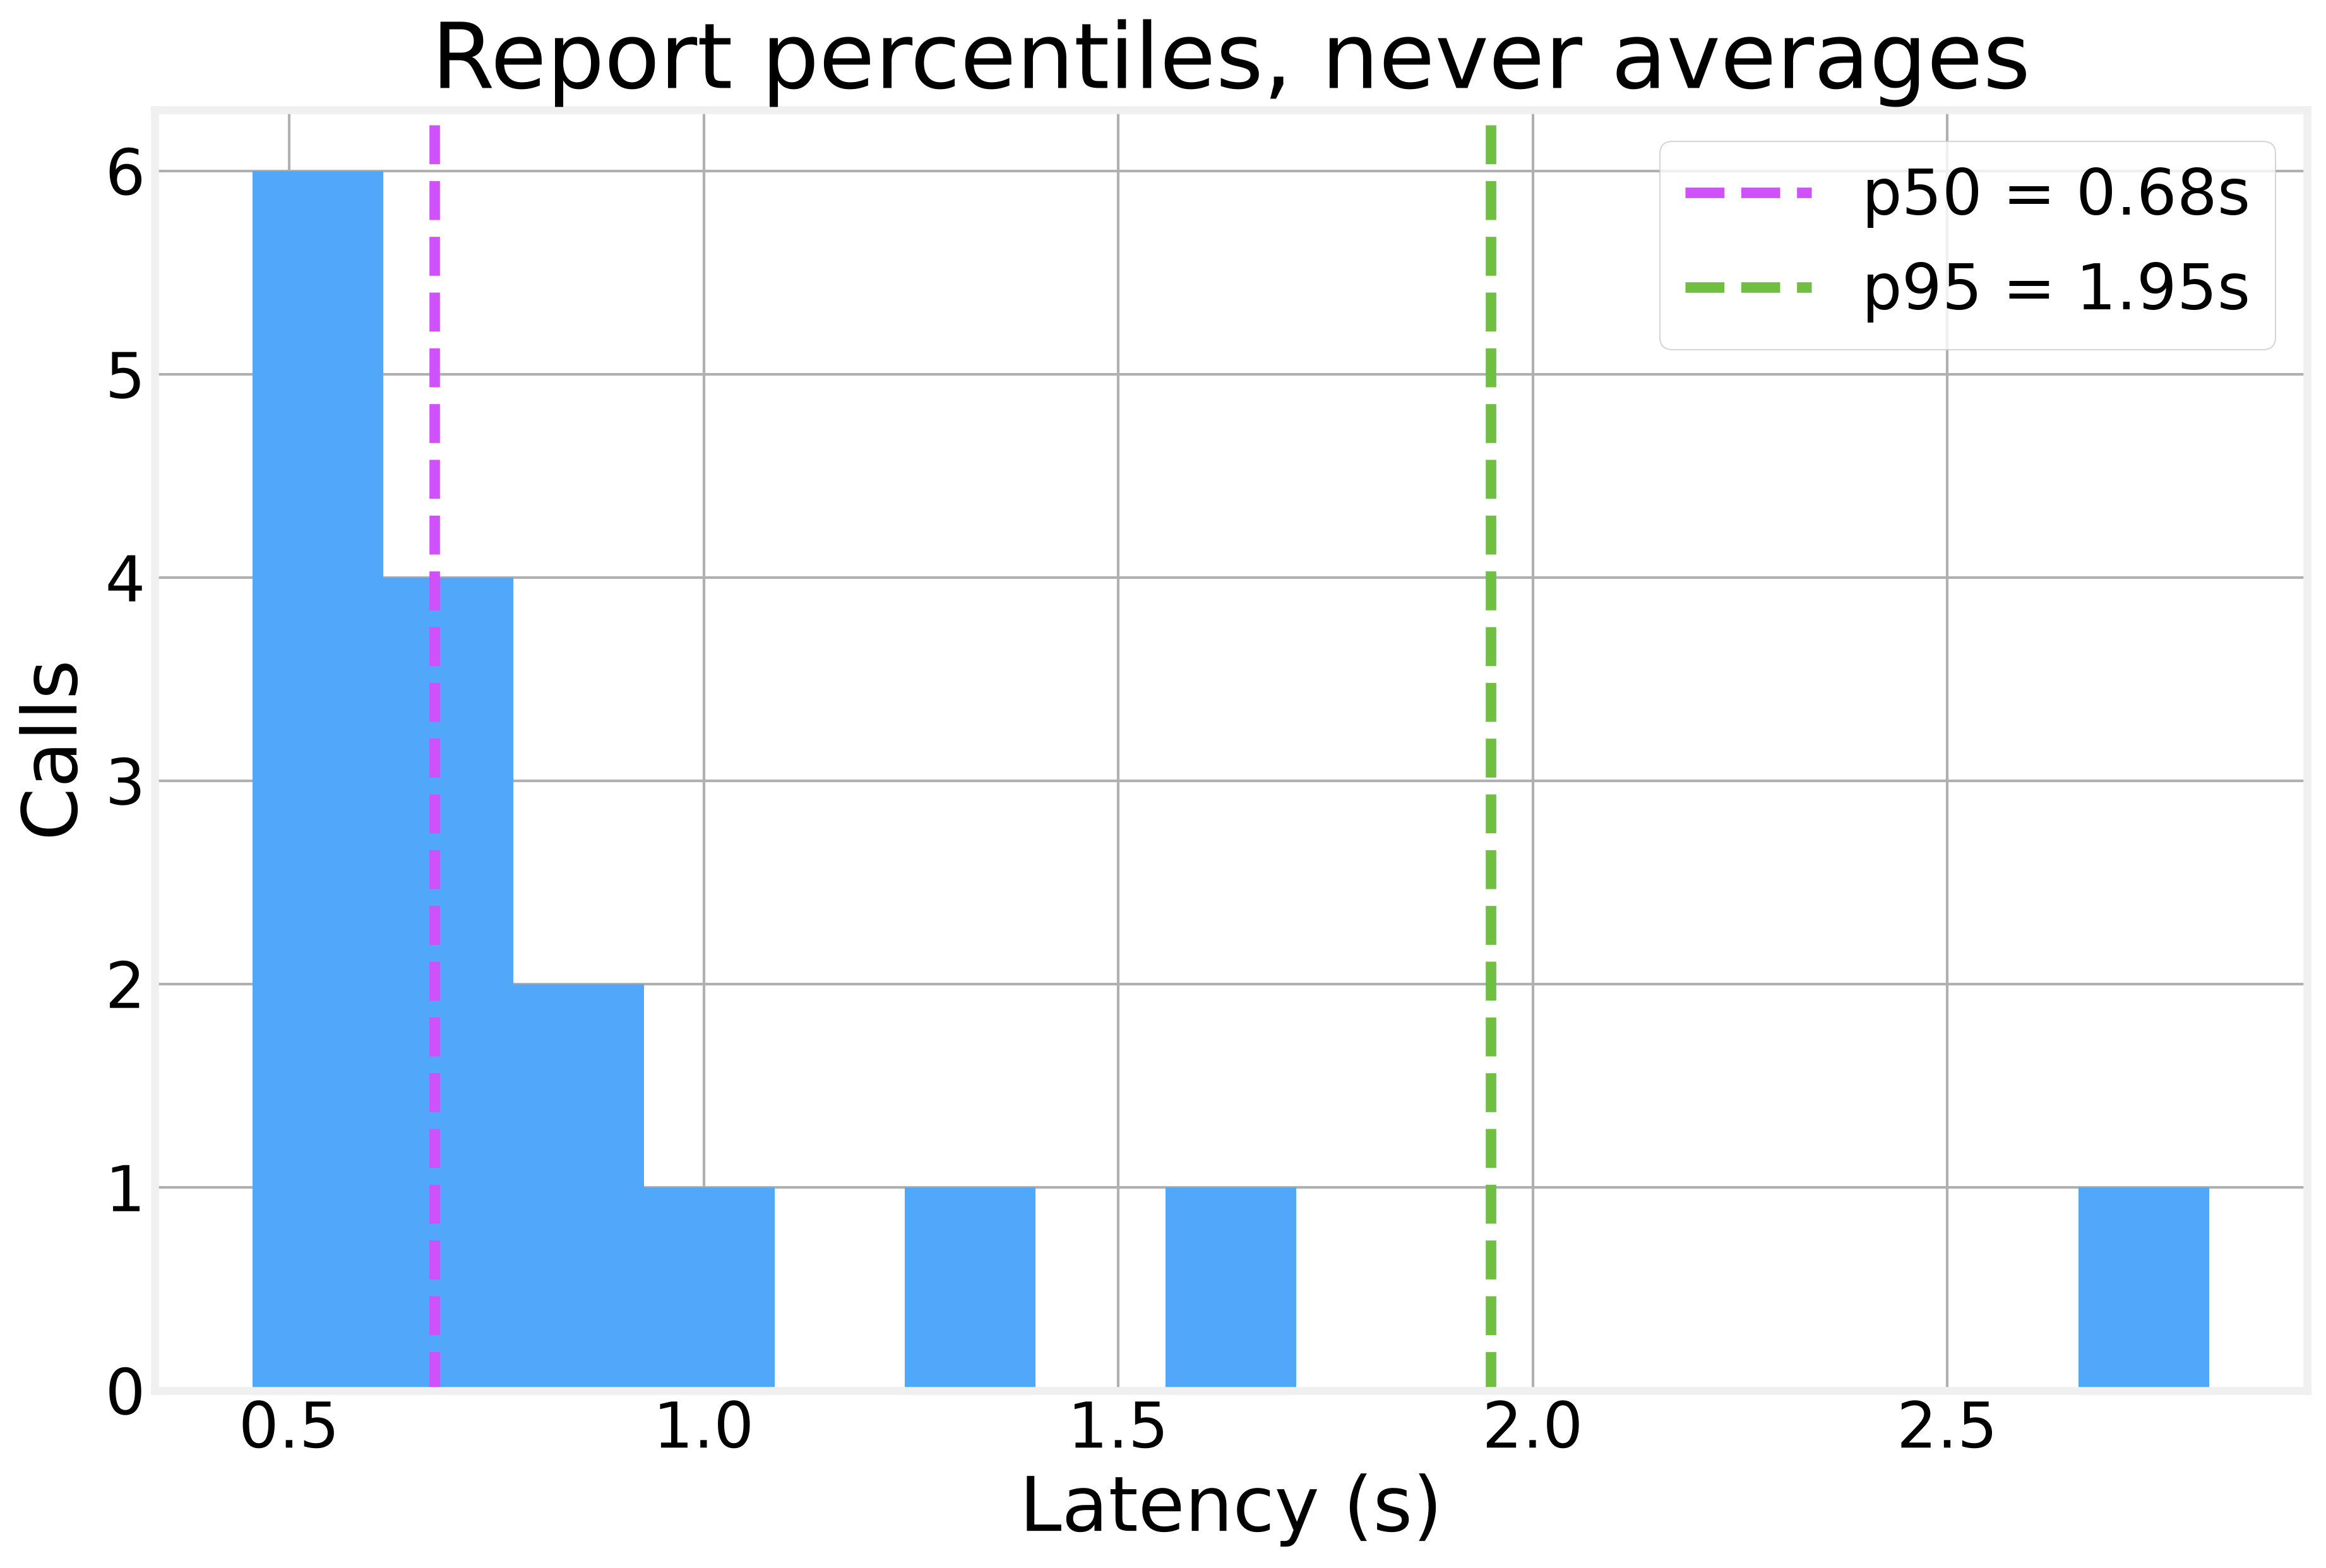

In [ ]:
latencies = trace["latency_s"].dropna()
p50 = latencies.quantile(0.50)
p95 = latencies.quantile(0.95)

fig, ax = plt.subplots()
ax.hist(latencies, bins=15, color=colors[0])
ax.axvline(p50, color=colors[1], linestyle="--", label=f"p50 = {p50:.2f}s")
ax.axvline(p95, color=colors[2], linestyle="--", label=f"p95 = {p95:.2f}s")
ax.set_xlabel("Latency (s)")
ax.set_ylabel("Calls")
ax.set_title("Report percentiles, never averages")
ax.legend()
fig.tight_layout()

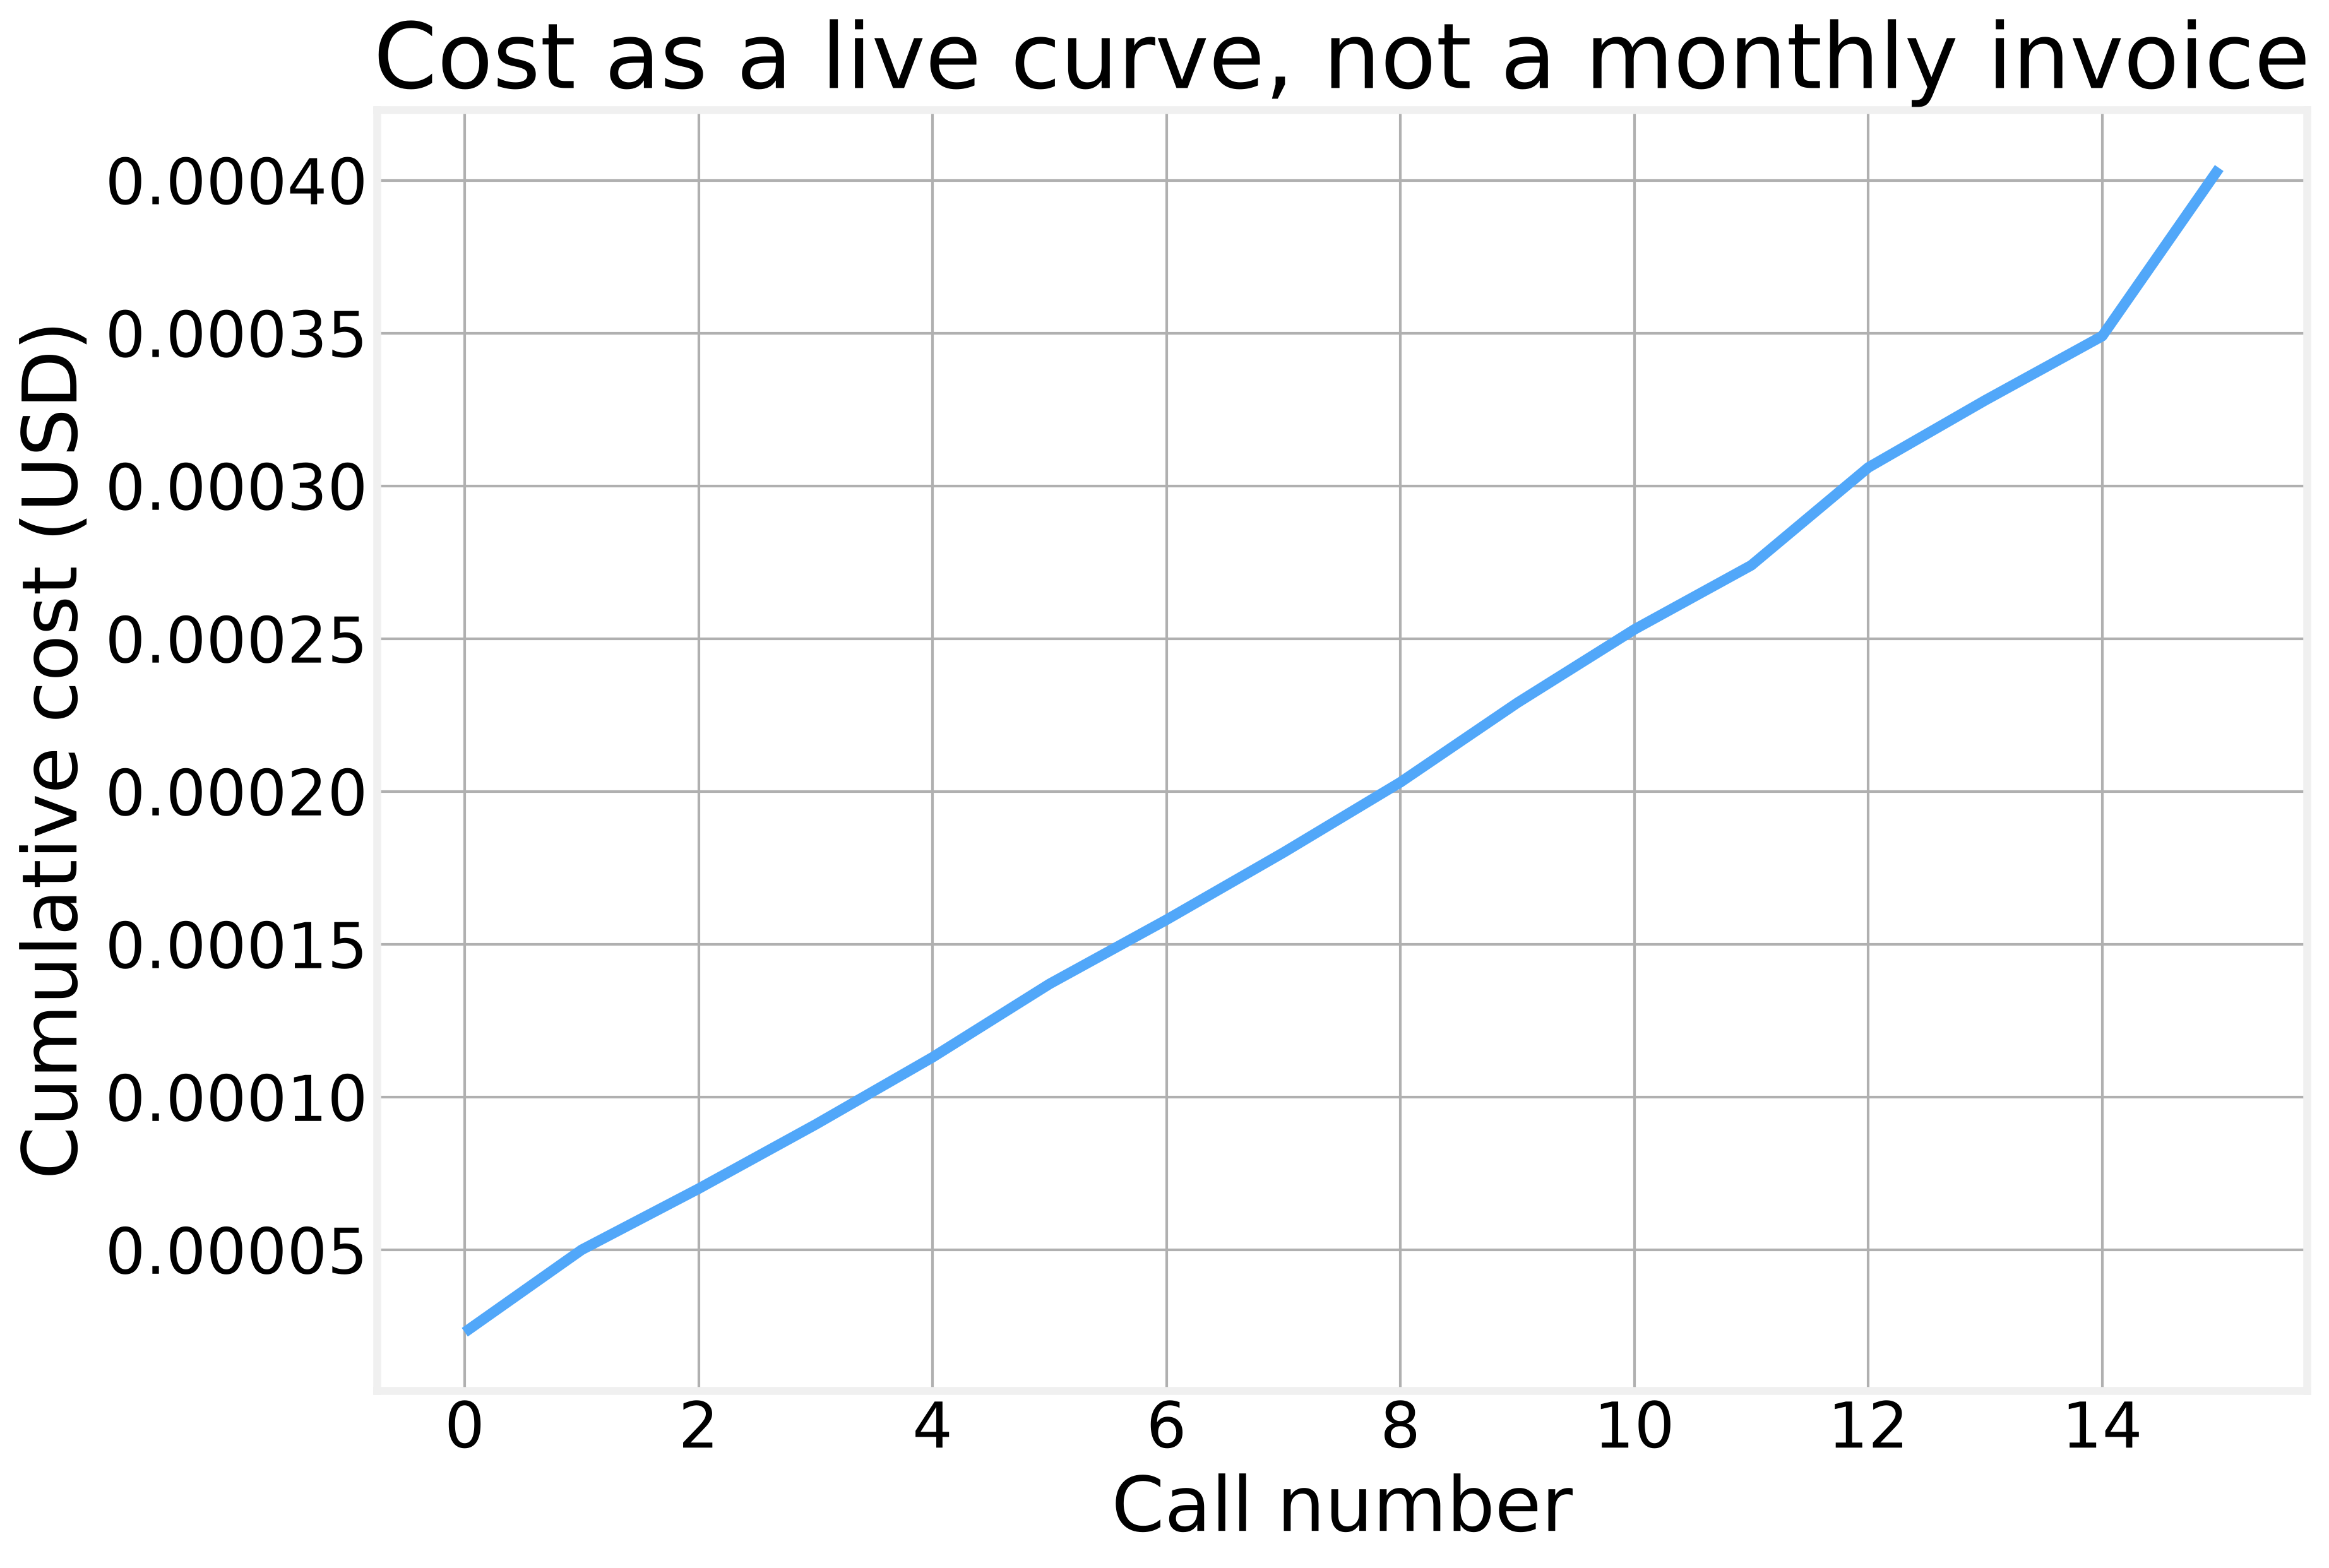

In [ ]:
cumulative = trace.sort_values("timestamp")["cost_usd"].cumsum().reset_index(drop=True)

fig, ax = plt.subplots()
ax.plot(cumulative.index, cumulative.values, color=colors[0])
ax.set_xlabel("Call number")
ax.set_ylabel("Cumulative cost (USD)")
ax.set_title("Cost as a live curve, not a monthly invoice")
fig.tight_layout()

# Caching: the cheapest token is the one you never buy

Exact match caching pays off whenever inputs repeat: retried jobs, duplicate messages, test suites. The key hashes model plus messages. Anything in neither belongs elsewhere.

In [23]:
CACHE_DIR = _OUT / "llm_cache"
CACHE_DIR.mkdir(exist_ok=True)

def cache_key(model, messages):
    payload = json.dumps({"model": model, "messages": messages}, sort_keys=True)
    return hashlib.sha256(payload.encode()).hexdigest()

def cached_llm(messages, model="gpt-4.1-mini", stage="default", **kwargs):
    key = CACHE_DIR / (cache_key(model, messages) + ".json")
    if key.exists():
        log_event(kind="cache_hit", stage=stage, model=model, cost_usd=0.0, latency_s=0.0)
        return json.loads(key.read_text())["content"]
    content = llm(messages, model=model, stage=stage, **kwargs)
    key.write_text(json.dumps({"content": content}))
    return content

# First pass fills the cache. Second pass rides it. Real traffic repeats more than you think.
for _ in range(2):
    for text in messages:
        cached_llm(
            [{"role": "system", "content": SYSTEM},
             {"role": "user", "content": text}],
            stage="triage_cached",
        )

fresh = pd.read_json(TRACE_PATH, lines=True)
fresh = fresh[(fresh["run_id"] == RUN_ID) & (fresh["stage"] == "triage_cached")]
hits = (fresh["kind"] == "cache_hit").sum()
spent = fresh["cost_usd"].sum()
print(f"{hits} cache hits out of {len(fresh)} calls. Total spend: {spent:.5f} USD.")


30 cache hits out of 30 calls. Total spend: 0.00000 USD.


### Provider side prompt caching

Providers also cache the prompt prefix itself. OpenAI applies it automatically once a stable prefix passes about a thousand tokens. Anthropic gives explicit control with `cache_control` blocks and bills cached reads at a fraction of the price.

The design rule is the same everywhere: put the stable parts first. System prompt, the 77 intent list and examples up top. The customer message last. Our triage prompt already follows this order.

# Deadlines and graceful degradation

A slow answer is a failure with better manners. Set a deadline. When the primary model misses it, a cheaper model answering on time beats an error page.

In [24]:
def call_with_deadline(messages, deadline_s=6.0):
    """Primary model under a deadline. On any failure, degrade to the cheap fallback."""
    try:
        return llm(messages, model="gpt-4.1-mini", stage="primary", timeout=deadline_s)
    except Exception as error:
        log_event(kind="fallback", reason=type(error).__name__)
        return llm(messages, model="gpt-4.1-nano", stage="fallback", timeout=deadline_s)

print(call_with_deadline([{"role": "user", "content": "Reply with one word: alive"}]))


Present


### Streaming buys perceived speed

Time to first token is the latency users feel.

In [25]:
stream = openai_client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{"role": "user", "content": "In one sentence: why stream responses to users?"}],
    stream=True,
)

for chunk in stream:
    print(chunk.choices[0].delta.content or "", end="", flush=True)
print()


Streaming responses enables users to receive information incrementally in real-time, improving responsiveness and user experience by reducing perceived latency.


# The regression gate

The eval harness from Notebook 2 becomes a command line tool with an exit code. CI runs it on every change to a prompt, the golden set, the taxonomy or the harness itself. Two thresholds: routing must stay above 0.85, diagnosis above 0.60.

In [26]:
%%writefile run_evals.py
"""Regression gate for the Banking77 triage prompt. Wire this into CI.

Usage:
    python run_evals.py --model gpt-4.1-mini --min-queue-accuracy 0.85 --min-intent-accuracy 0.60
"""
import argparse
import json
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import Literal

from openai import OpenAI
from pydantic import BaseModel


def main():
    parser = argparse.ArgumentParser(description="LLM regression gate")
    parser.add_argument("--model", default="gpt-4.1-mini")
    parser.add_argument("--dataset", default="data/golden_banking77.jsonl")
    parser.add_argument("--taxonomy", default="data/banking77_taxonomy.json")
    parser.add_argument("--prompt", default="prompts/triage_v1.0.0.json")
    parser.add_argument("--min-queue-accuracy", type=float, default=0.85)
    parser.add_argument("--min-intent-accuracy", type=float, default=0.60)
    parser.add_argument("--workers", type=int, default=8)
    args = parser.parse_args()

    taxonomy = json.loads(Path(args.taxonomy).read_text())
    prompt = json.loads(Path(args.prompt).read_text())
    golden = [json.loads(line) for line in Path(args.dataset).read_text().splitlines()]
    intents = ", ".join(taxonomy["intents"])
    client = OpenAI()

    class Triage(BaseModel):
        queue: Literal[tuple(taxonomy["queues"])]
        intent: Literal[tuple(taxonomy["intents"])]
        summary: str
        requires_human: bool

    def score(row):
        response = client.chat.completions.parse(
            model=args.model,
            messages=[{"role": "system", "content": prompt["system"]},
                      {"role": "user", "content": prompt["user_template"].format(text=row["text"], intents=intents)}],
            response_format=Triage,
            temperature=0,
        )
        prediction = response.choices[0].message.parsed
        return prediction.queue == row["queue"], prediction.intent == row["intent"]

    with ThreadPoolExecutor(max_workers=args.workers) as pool:
        results = list(pool.map(score, golden))

    queue_accuracy = sum(q for q, _ in results) / len(results)
    intent_accuracy = sum(i for _, i in results) / len(results)
    print(f"queue accuracy:  {queue_accuracy:.3f} (threshold {args.min_queue_accuracy})")
    print(f"intent accuracy: {intent_accuracy:.3f} (threshold {args.min_intent_accuracy})")
    print(f"n = {len(results)}  model = {args.model}  prompt = {prompt['version']}")

    if queue_accuracy < args.min_queue_accuracy or intent_accuracy < args.min_intent_accuracy:
        print("FAIL: below threshold. Blocking the deploy.")
        sys.exit(1)
    print("PASS")


if __name__ == "__main__":
    main()


Overwriting run_evals.py


In [27]:
!python run_evals.py --help


usage: run_evals.py [-h] [--model MODEL] [--dataset DATASET]
                    [--taxonomy TAXONOMY] [--prompt PROMPT]
                    [--min-queue-accuracy MIN_QUEUE_ACCURACY]
                    [--min-intent-accuracy MIN_INTENT_ACCURACY]
                    [--workers WORKERS]

LLM regression gate

options:
  -h, --help            show this help message and exit
  --model MODEL
  --dataset DATASET
  --taxonomy TAXONOMY
  --prompt PROMPT
  --min-queue-accuracy MIN_QUEUE_ACCURACY
  --min-intent-accuracy MIN_INTENT_ACCURACY
  --workers WORKERS


In [28]:
%%writefile evals.yml
# Drop into .github/workflows/ to gate every prompt change.
name: llm-regression-suite

on:
  pull_request:
    paths:
      - "prompts/**"
      - "run_evals.py"
      - "data/golden_banking77.jsonl"
      - "data/banking77_taxonomy.json"

jobs:
  evals:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"
      - run: pip install openai pydantic
      - run: python run_evals.py --min-queue-accuracy 0.85 --min-intent-accuracy 0.60
        env:
          OPENAI_API_KEY: ${{ secrets.OPENAI_API_KEY }}


Overwriting evals.yml


# The production readiness checklist

**Before launch**
1. Prompts versioned in files with changelogs
2. Structured outputs validated, with one repair attempt
3. Golden set sampled or labeled, seeded and stored with the code
4. Baseline eval report saved and dated

**Observe**
5. Every call traced: model, tokens, cost, latency, stage
6. Latency reported as p50 and p95, never as a mean
7. Cost visible per stage and per day, not per invoice

**Control**
8. Exact match cache for repeated inputs, stable prefix ordering for provider caches
9. Deadlines with a fallback model, retries on reads only
10. Step and token budgets on every agent loop

**Gate**
11. Regression suite in CI with hard thresholds and a nonzero exit code
12. Model and prompt changes ship through the gate, no exceptions

# Where you started, where you are

This morning a prompt was a string in the code. Now, on 13,083 real banking messages:

1. Prompts are versioned, schema checked and regression tested.
2. A seeded golden set and a harness turn opinions into numbers at two levels of the taxonomy.
3. Model choices carry confidence intervals and a cost column.
4. Retrieval has recall@k and MRR before generation gets a vote.
5. The agent validates, gates, retries and degrades on purpose.
6. Production has a flight recorder, a cache, deadlines and a CI gate.

That is the whole discipline. Point it at your own data on Monday morning.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>